In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler yüklendi!")
print("\nProje: Türkçe Haber Kategorisi Sınıflandırıcı")
print("Model: BERTurk (Türkçe BERT)")
print("Kategoriler: Spor, Ekonomi, Teknoloji, Siyaset, Sağlık")

C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kütüphaneler yüklendi!

Proje: Türkçe Haber Kategorisi Sınıflandırıcı
Model: BERTurk (Türkçe BERT)
Kategoriler: Spor, Ekonomi, Teknoloji, Siyaset, Sağlık


Toplam örnek: 60

Kategori dağılımı:
kategori
Spor         12
Ekonomi      12
Teknoloji    12
Siyaset      12
Sağlık       12
Name: count, dtype: int64


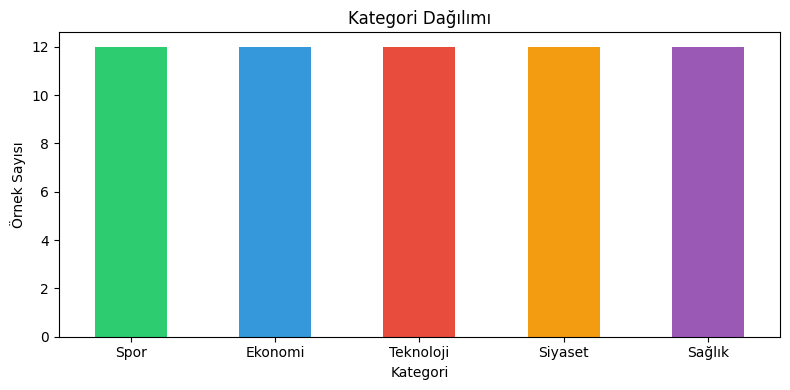

In [2]:
# Türkçe haber başlıkları veri seti
haberler = [
    # Spor (0)
    ("Galatasaray şampiyonluk maçında rakibini 3-0 mağlup etti", 0),
    ("Milli takım dünya kupası elemelerinde güçlü başladı", 0),
    ("Fenerbahçe yeni sezon transferlerini açıkladı", 0),
    ("Beşiktaş Avrupa liginde çeyrek finale yükseldi", 0),
    ("Türk tenisçi grand slam turnuvasında finale kaldı", 0),
    ("Basketbol liginde play-off heyecanı başladı", 0),
    ("Milli yüzücü dünya rekoru kırdı", 0),
    ("Süper Lig'de haftanın golü seçildi", 0),
    ("Trabzonspor deplasmanda kritik galibiyet aldı", 0),
    ("Olimpiyat şampiyonu sporcu ülkeye döndü", 0),
    ("Formula 1 pilotu pist rekoru kırdı", 0),
    ("Voleybol milli takımı Avrupa şampiyonu oldu", 0),

    # Ekonomi (1)
    ("Merkez Bankası faiz kararını açıkladı", 1),
    ("Dolar kuru bugün rekor seviyeye ulaştı", 1),
    ("Enflasyon verileri beklentilerin üzerinde geldi", 1),
    ("Borsa İstanbul'da sert yükseliş yaşandı", 1),
    ("Bütçe açığı geçen yıla göre azaldı", 1),
    ("İhracat rakamları tarihi zirveyi gördü", 1),
    ("Petrol fiyatları küresel piyasalarda düştü", 1),
    ("Yeni ekonomi paketi açıklandı", 1),
    ("Altın fiyatları yükselmeye devam ediyor", 1),
    ("Türkiye büyüme rakamlarını açıkladı", 1),
    ("Vergi düzenlemesi meclisten geçti", 1),
    ("Asgari ücret artışı açıklandı", 1),

    # Teknoloji (2)
    ("Yapay zeka alanında çığır açan yeni model geliştirildi", 2),
    ("Türk girişimi milyar dolarlık yatırım aldı", 2),
    ("Elektrikli araç batarya teknolojisinde devrim", 2),
    ("Siber güvenlik açığı milyonlarca kullanıcıyı etkiledi", 2),
    ("Yeni nesil işlemci rekor hız kırdı", 2),
    ("Uzay şirketi uydu fırlatma testini başarıyla tamamladı", 2),
    ("5G altyapısı genişleme çalışmaları hız kazandı", 2),
    ("Robotik cerrahi ameliyatı başarıyla gerçekleştirildi", 2),
    ("Metaverse platformu yeni özellikler sundu", 2),
    ("Kuantum bilgisayar testi başarıyla tamamlandı", 2),
    ("Sosyal medya algoritması değişikliği duyuruldu", 2),
    ("Yerli yazılım şirketi uluslararası pazara açıldı", 2),

    # Siyaset (3)
    ("Cumhurbaşkanı kritik ziyaret için Ankara'da", 3),
    ("Meclis genel kurulunda önemli yasa kabul edildi", 3),
    ("Dışişleri Bakanı uluslararası görüşme gerçekleştirdi", 3),
    ("Muhalefet partisi yeni strateji belirledi", 3),
    ("NATO zirvesinde kritik kararlar alındı", 3),
    ("Seçim takvimi resmi olarak açıklandı", 3),
    ("Hükümet yeni kabine değişikliğini duyurdu", 3),
    ("BM'de Türkiye'nin önergesi kabul edildi", 3),
    ("İkili anlaşma imzalandı", 3),
    ("Siyasi parti kongresinde yeni başkan seçildi", 3),
    ("Diplomatik kriz müzakerelerle çözüldü", 3),
    ("Anayasa değişikliği oylaması gerçekleşti", 3),

    # Sağlık (4)
    ("Yeni kanser ilacı klinik deneylerde başarılı sonuç verdi", 4),
    ("Grip salgınına karşı aşılama kampanyası başladı", 4),
    ("Sağlık Bakanlığı yeni hastane projelerini açıkladı", 4),
    ("Organ bağışı kampanyası rekor katılıma ulaştı", 4),
    ("Yeni nesil antibiyotik dirençli bakterilere karşı etkili", 4),
    ("Beyin cerrahisinde yeni teknik geliştirildi", 4),
    ("Korona virüs varyantı takip altında", 4),
    ("Diyabet tedavisinde çığır açan buluş", 4),
    ("Sağlıklı beslenme raporu yayınlandı", 4),
    ("Psikolojik sağlık hizmetleri yaygınlaştırılıyor", 4),
    ("Çocuk hastalıkları aşı programı güncellendi", 4),
    ("Yapay zeka destekli tanı sistemi hastanelerde", 4),
]

df = pd.DataFrame(haberler, columns=['metin', 'etiket'])
kategoriler = {0: 'Spor', 1: 'Ekonomi', 2: 'Teknoloji', 3: 'Siyaset', 4: 'Sağlık'}
df['kategori'] = df['etiket'].map(kategoriler)

print(f"Toplam örnek: {len(df)}")
print(f"\nKategori dağılımı:")
print(df['kategori'].value_counts())

# Görselleştir
plt.figure(figsize=(8, 4))
df['kategori'].value_counts().plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'])
plt.title("Kategori Dağılımı")
plt.xlabel("Kategori")
plt.ylabel("Örnek Sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [3]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    df['metin'].tolist(),
    df['etiket'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['etiket']
)

print(f"Train: {len(X_train)} örnek")
print(f"Test:  {len(X_test)} örnek")

# BERTurk tokenizer — Türkçe BERT
print("\nBERTurk tokenizer yükleniyor...")
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-uncased")

# Test et
test_cümle = "Galatasaray şampiyonluk maçını kazandı"
tokens = tokenizer.tokenize(test_cümle)
print(f"\nTest cümlesi: '{test_cümle}'")
print(f"Tokenlar: {tokens}")
print(f"Token sayısı: {len(tokens)}")
print(f"Vocab boyutu: {tokenizer.vocab_size}")

Train: 48 örnek
Test:  12 örnek

BERTurk tokenizer yükleniyor...



Test cümlesi: 'Galatasaray şampiyonluk maçını kazandı'
Tokenlar: ['galatasaray', 'sam', '##pi', '##yon', '##luk', 'mac', '##ını', 'kazandı']
Token sayısı: 8
Vocab boyutu: 32000


In [4]:
class HaberDataset(Dataset):
    def __init__(self, metinler, etiketler, tokenizer, max_len=64):
        self.metinler = metinler
        self.etiketler = etiketler
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.metinler)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.metinler[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.etiketler[idx], dtype=torch.long)
        }

# Dataset ve DataLoader oluştur
train_dataset = HaberDataset(X_train, y_train, tokenizer)
test_dataset = HaberDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Train dataset: {len(train_dataset)} örnek")
print(f"Test dataset:  {len(test_dataset)} örnek")
print(f"Train batch sayısı: {len(train_loader)}")

# Bir örneğe bakalım
örnek = train_dataset[0]
print(f"\nBir örnek:")
print(f"input_ids shape: {örnek['input_ids'].shape}")
print(f"attention_mask shape: {örnek['attention_mask'].shape}")
print(f"label: {örnek['label']} ({kategoriler[örnek['label'].item()]})")

Train dataset: 48 örnek
Test dataset:  12 örnek
Train batch sayısı: 6

Bir örnek:
input_ids shape: torch.Size([64])
attention_mask shape: torch.Size([64])
label: 4 (Sağlık)


In [5]:
print("BERTurk modeli yükleniyor...")
model = AutoModelForSequenceClassification.from_pretrained(
    "dbmdz/bert-base-turkish-uncased",
    num_labels=5
)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam parametre: {total_params:,}")
print(f"Eğitilecek parametre: {trainable:,}")
print("\nEğitim başlıyor...")

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(10):
    # Eğitim
    model.train()
    total_loss, correct = 0, 0

    for batch in train_loader:
        optimizer.zero_grad()
        output = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )
        loss = criterion(output.logits, batch['label'])
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.logits.argmax(1) == batch['label']).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / len(train_dataset)

    # Test
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            output = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask']
            )
            loss = criterion(output.logits, batch['label'])
            total_loss += loss.item()
            correct += (output.logits.argmax(1) == batch['label']).sum().item()

    test_loss = total_loss / len(test_loader)
    test_acc = correct / len(test_dataset)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:2d}/10 | Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} Acc: {test_acc:.2%}")

BERTurk modeli yükleniyor...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7417.21it/s]
BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; 

Toplam parametre: 110,621,189
Eğitilecek parametre: 110,621,189

Eğitim başlıyor...
Epoch  1/10 | Train Loss: 1.6274 Acc: 20.83% | Test Loss: 1.5725 Acc: 50.00%
Epoch  2/10 | Train Loss: 1.5239 Acc: 37.50% | Test Loss: 1.5136 Acc: 41.67%
Epoch  3/10 | Train Loss: 1.4436 Acc: 60.42% | Test Loss: 1.4000 Acc: 83.33%
Epoch  4/10 | Train Loss: 1.2941 Acc: 64.58% | Test Loss: 1.3505 Acc: 75.00%
Epoch  5/10 | Train Loss: 1.1487 Acc: 79.17% | Test Loss: 1.1613 Acc: 91.67%
Epoch  6/10 | Train Loss: 0.9743 Acc: 85.42% | Test Loss: 1.0061 Acc: 91.67%


KeyboardInterrupt: 

Classification Report:
              precision    recall  f1-score   support

        Spor       1.00      1.00      1.00         3
     Ekonomi       1.00      1.00      1.00         2
   Teknoloji       1.00      1.00      1.00         2
     Siyaset       1.00      1.00      1.00         3
      Sağlık       1.00      1.00      1.00         2

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



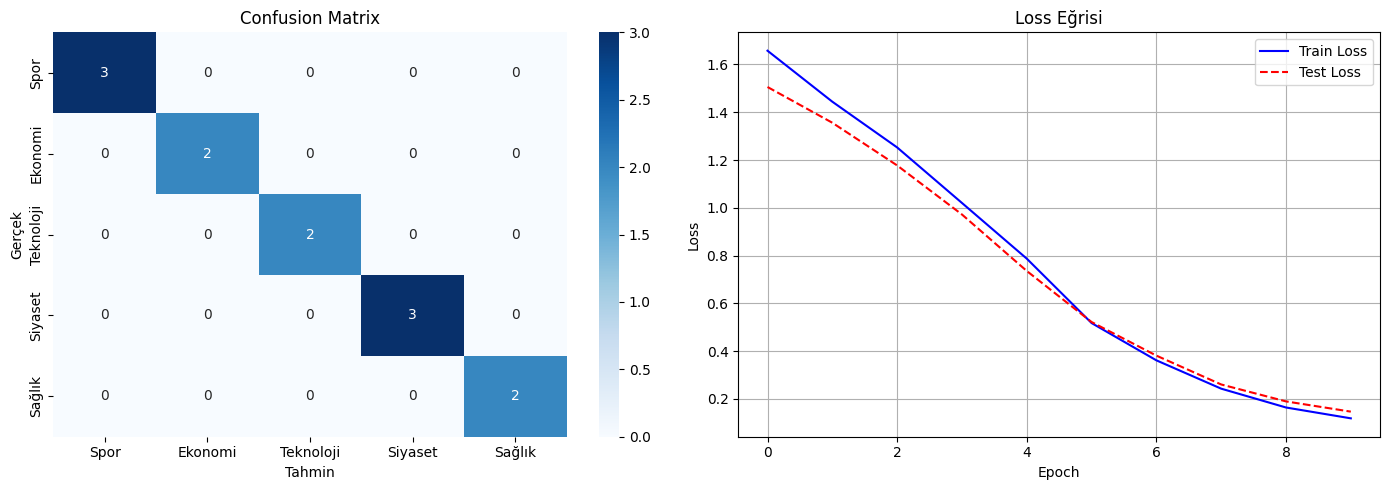

In [ ]:
# Confusion Matrix ve Classification Report
model.eval()
tüm_tahminler = []
tüm_gerçekler = []

with torch.no_grad():
    for batch in test_loader:
        output = model(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask']
        )
        tahminler = output.logits.argmax(1).tolist()
        gerçekler = batch['label'].tolist()
        tüm_tahminler.extend(tahminler)
        tüm_gerçekler.extend(gerçekler)

# Classification Report
print("Classification Report:")
print("=" * 55)
print(classification_report(
    tüm_gerçekler,
    tüm_tahminler,
    target_names=list(kategoriler.values())
))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(tüm_gerçekler, tüm_tahminler)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(kategoriler.values()),
            yticklabels=list(kategoriler.values()),
            ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gerçek")

# Loss eğrisi
axes[1].plot(train_losses, label='Train Loss', color='blue')
axes[1].plot(test_losses, label='Test Loss', color='red', linestyle='--')
axes[1].set_title("Loss Eğrisi")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def tahmin_et(metin, model, tokenizer, kategoriler):
    model.eval()
    encoding = tokenizer(
        metin,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        output = model(
            input_ids=encoding['input_ids'],
            attention_mask=encoding['attention_mask']
        )
    probs = torch.softmax(output.logits, dim=1)[0]
    pred = probs.argmax().item()

    print(f"📰 Haber: '{metin}'")
    print(f"🎯 Tahmin: {kategoriler[pred]} ({probs[pred]:.2%})")
    print("📊 Tüm olasılıklar:")
    for i, (kat, prob) in enumerate(zip(kategoriler.values(), probs)):
        bar = "█" * int(prob.item() * 20)
        print(f"   {kat:12s} {bar} {prob:.2%}")
    print()

# Test et — hiç görmediği cümleler
test_haberler = [
    "Beşiktaş bu sezon şampiyonluk için güçlü aday",
    "Merkez Bankası faiz oranını yüzde beş artırdı",
    "Yeni yapay zeka modeli insan beynini taklit ediyor",
    "Muhalefet lideri hükümeti sert eleştirdi",
    "Yeni aşı çalışmaları olumlu sonuç verdi",
    "Türk bilim insanı Nobel ödülüne aday gösterildi",  # Zor — hangi kategori?
]

print("=" * 55)
for haber in test_haberler:
    tahmin_et(haber, model, tokenizer, kategoriler)

📰 Haber: 'Beşiktaş bu sezon şampiyonluk için güçlü aday'
🎯 Tahmin: Spor (92.42%)
📊 Tüm olasılıklar:
   Spor         ██████████████████ 92.42%
   Ekonomi       1.07%
   Teknoloji     1.09%
   Siyaset       2.84%
   Sağlık        2.58%

📰 Haber: 'Merkez Bankası faiz oranını yüzde beş artırdı'
🎯 Tahmin: Ekonomi (92.63%)
📊 Tüm olasılıklar:
   Spor          1.31%
   Ekonomi      ██████████████████ 92.63%
   Teknoloji     1.56%
   Siyaset       2.54%
   Sağlık        1.95%

📰 Haber: 'Yeni yapay zeka modeli insan beynini taklit ediyor'
🎯 Tahmin: Teknoloji (81.08%)
📊 Tüm olasılıklar:
   Spor          1.75%
   Ekonomi       2.33%
   Teknoloji    ████████████████ 81.08%
   Siyaset       2.38%
   Sağlık       ██ 12.46%

📰 Haber: 'Muhalefet lideri hükümeti sert eleştirdi'
🎯 Tahmin: Siyaset (84.83%)
📊 Tüm olasılıklar:
   Spor          3.26%
   Ekonomi      █ 7.89%
   Teknoloji     2.41%
   Siyaset      ████████████████ 84.83%
   Sağlık        1.61%

📰 Haber: 'Yeni aşı çalışmaları olumlu sonuç verdi

In [ ]:
import os

# Modeli kaydet
os.makedirs("model", exist_ok=True)
model.save_pretrained("model/turkce_haber_model")
tokenizer.save_pretrained("model/turkce_haber_tokenizer")
print("✅ Model kaydedildi: model/turkce_haber_model")

# Modeli yükle ve test et
print("\nModel yeniden yükleniyor...")
loaded_model = AutoModelForSequenceClassification.from_pretrained("model/turkce_haber_model")
loaded_tokenizer = AutoTokenizer.from_pretrained("model/turkce_haber_tokenizer")
print("✅ Model başarıyla yüklendi!")

# Yüklenen modelle test et
print("\nYüklenen modelle test:")
print("=" * 55)
tahmin_et(
    "Galatasaray kupayı kazandı",
    loaded_model,
    loaded_tokenizer,
    kategoriler
)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.14it/s]


✅ Model kaydedildi: model/turkce_haber_model

Model yeniden yükleniyor...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2887.83it/s]


✅ Model başarıyla yüklendi!

Yüklenen modelle test:
📰 Haber: 'Galatasaray kupayı kazandı'
🎯 Tahmin: Spor (92.92%)
📊 Tüm olasılıklar:
   Spor         ██████████████████ 92.92%
   Ekonomi       1.40%
   Teknoloji     1.45%
   Siyaset       2.35%
   Sağlık        1.89%

